In [1]:
import warnings
warnings.filterwarnings("ignore")
import random

In [2]:
"""
Hilbert 13 -> Kolmogorov-Arnold -> Redes Neurais
1) Plota um polinômio arbitrário p(x)
2) Treina um MLPRegressor (scikit-learn) para aproximá-lo via regressão
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# ------------------------------------------------------------------
# 1) Polinômio arbitrário (troque os coeficientes à vontade)
# ------------------------------------------------------------------
coeffs = [0.5, -2, -1, 3, -4]   # do maior para o menor grau
p = np.poly1d(coeffs)
print("Polinômio escolhido:\n", p)

Polinômio escolhido:
      4     3     2
0.5 x - 2 x - 1 x + 3 x - 4


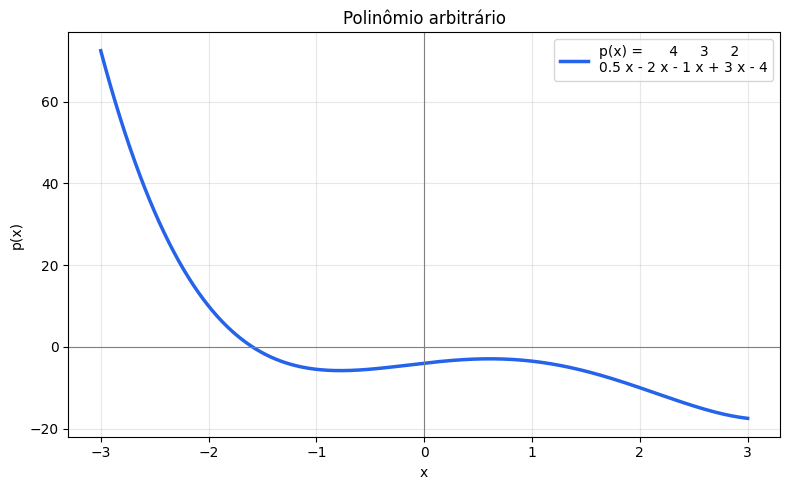

In [4]:
x_plot = np.linspace(-3, 3, 400)
y_plot = p(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, color="#2563eb", linewidth=2.5, label=f"p(x) = {p}")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Polinômio arbitrário")
plt.xlabel("x"); plt.ylabel("p(x)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("1_polinomio.png", dpi=150)
plt.show()

In [5]:
# ------------------------------------------------------------------
# 2) Dados de treino/teste (com ruído, para simular regressão real)
# ------------------------------------------------------------------
rng = np.random.default_rng(42)
X = rng.uniform(-3, 3, size=(600, 1))
y_true = p(X.ravel())
y = y_true + rng.normal(0, 1.0, size=y_true.shape)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_x = StandardScaler().fit(X_train)
X_train_s = scaler_x.transform(X_train)
X_test_s = scaler_x.transform(X_test)

In [7]:
len(X_train)

480

In [8]:
len(X_test)

120

In [9]:
X[0]

array([1.64373629])

In [10]:
y[0]

np.float64(-5.7549823466152805)

In [11]:
n = 0
while (n <10):
    cel_p = random.randint(0,600)
    print(X[cel_p], y[cel_p])
    n = n + 1

[-1.40122009] -2.448295907579934
[1.56683821] -7.506251260356963
[2.59813933] -15.826925407784772
[-2.6665925] 43.81670620933642
[0.52983749] -2.5045646277344082
[1.70338925] -8.335848816731128
[2.97278684] -18.50985406778868
[1.7085807] -8.136109100499203
[0.50458781] -3.9290160867100377
[2.45148414] -13.64217249158322


In [12]:
# ------------------------------------------------------------------
# 3) Rede neural (MLPRegressor) — análoga à estrutura Kolmogorov-Arnold
# ------------------------------------------------------------------
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="tanh",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=5000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42,
)

In [13]:
mlp.fit(X_train_s, y_train)

y_pred_test = mlp.predict(X_test_s)
print(f"MSE = {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"R^2 = {r2_score(y_test, y_pred_test):.4f}")

MSE = 1.6146
R^2 = 0.9947


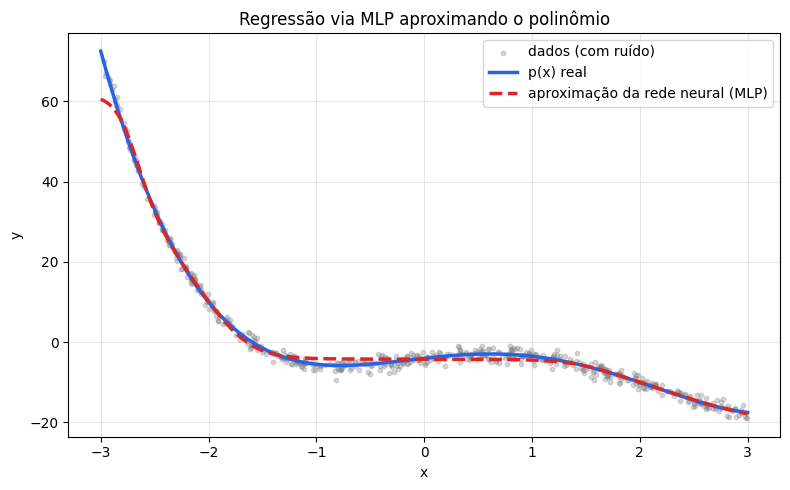

In [14]:
# ------------------------------------------------------------------
# 4) Comparação visual: polinômio real vs. aproximação da rede
# ------------------------------------------------------------------
x_dense = np.linspace(-3, 3, 400).reshape(-1, 1)
x_dense_s = scaler_x.transform(x_dense)
y_dense_true = p(x_dense.ravel())
y_dense_pred = mlp.predict(x_dense_s)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=10, alpha=0.3, color="gray", label="dados (com ruído)")
plt.plot(x_dense, y_dense_true, color="#2563eb", linewidth=2.5, label="p(x) real")
plt.plot(x_dense, y_dense_pred, color="#dc2626", linewidth=2.5, linestyle="--",
         label="aproximação da rede neural (MLP)")
plt.title("Regressão via MLP aproximando o polinômio")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("2_regressao_mlp.png", dpi=150)
plt.show()

In [20]:
print("mlp 1")
print(f"MSE = {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"R^2 = {r2_score(y_test, y_pred_test):.4f}")

mlp 1
MSE = 2.5039
R^2 = 0.9918


In [21]:
mlp_2 = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="tanh",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-2,
    max_iter=10000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42,
)
mlp_2.fit(X_train_s, y_train)
y_pred_test = mlp_2.predict(X_test_s)
print("mlp 2")
print(f"MSE = {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"R^2 = {r2_score(y_test, y_pred_test):.4f}")

mlp 2
MSE = 1.2538
R^2 = 0.9959


In [22]:
mlp_3 = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="tanh",
    solver="adam",
    alpha=1e-3,
    learning_rate_init=1e-1,
    max_iter=20000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42,
)
mlp_3.fit(X_train_s, y_train)
y_pred_test = mlp_3.predict(X_test_s)
print("mlp 3")
print(f"MSE = {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"R^2 = {r2_score(y_test, y_pred_test):.4f}")

mlp 3
MSE = 2.5039
R^2 = 0.9918
